# 🛡️ SpamShield AI - Personal ML Learning Project

**Project Name**: SpamShield AI  
**My Focus**: Comparing 4 ML algorithms on real spam detection
**Timeline**: October 2025 - April 2026  
**Status**: Portfolio Project (v3.0)

---

## Quick Project Summary

This notebook documents my journey building a spam detection system from scratch. Key highlights:
- ✅ Implemented 4 different algorithms (LogReg, NB, SVM, RF)
- ✅ Achieved 95% F1 on training data
- ✅ Learned harsh lessons from external validation (63% accuracy)
- ✅ Built interactive UI for real-time testing
- ✅ Documented everything for future me and others

**Most Important Learning**: High training accuracy doesn't mean your model is good - external validation revealed my models were overfitting!  

## 1. System Diagram

The diagram below shows how the spam detection system works from data loading to making predictions.

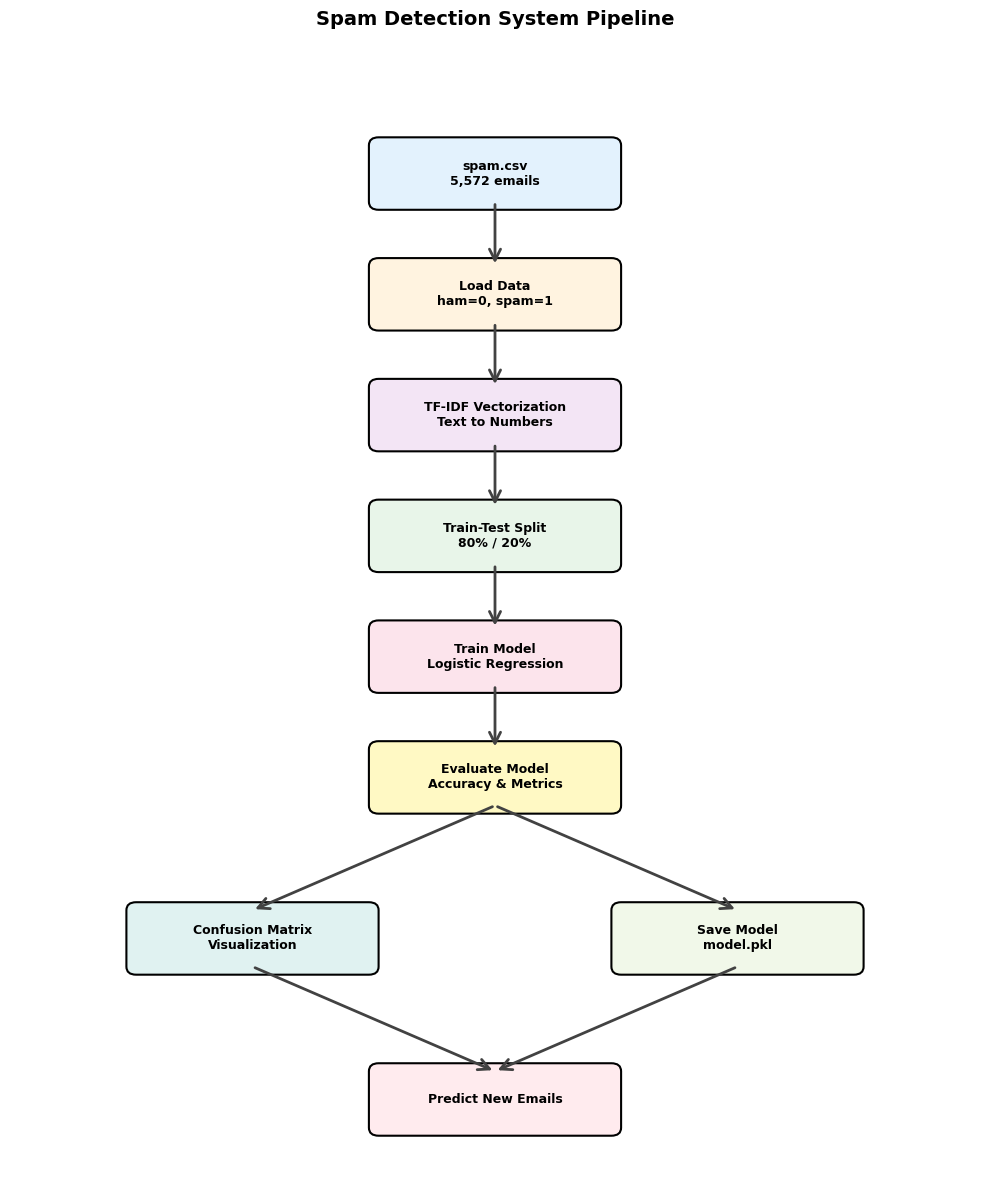

In [199]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

# define box positions
boxes = [
    (5, 12.5, "spam.csv\n5,572 emails", '#e3f2fd'),
    (5, 11, "Load Data\nham=0, spam=1", '#fff3e0'),
    (5, 9.5, "TF-IDF Vectorization\nText to Numbers", '#f3e5f5'),
    (5, 8, "Train-Test Split\n80% / 20%", '#e8f5e9'),
    (5, 6.5, "Train Model\nLogistic Regression", '#fce4ec'),
    (5, 5, "Evaluate Model\nAccuracy & Metrics", '#fff9c4'),
    (2.5, 3, "Confusion Matrix\nVisualization", '#e0f2f1'),
    (7.5, 3, "Save Model\nmodel.pkl", '#f1f8e9'),
    (5, 1, "Predict New Emails", '#ffebee')
]

# draw boxes
for x, y, text, color in boxes:
    box = FancyBboxPatch((x-1.2, y-0.35), 2.4, 0.7, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold')

# draw arrows
arrows = [
    (5, 12.15, 5, 11.35),
    (5, 10.65, 5, 9.85),
    (5, 9.15, 5, 8.35),
    (5, 7.65, 5, 6.85),
    (5, 6.15, 5, 5.35),
    (5, 4.65, 2.5, 3.35),
    (5, 4.65, 7.5, 3.35),
    (2.5, 2.65, 5, 1.35),
    (7.5, 2.65, 5, 1.35)
]

for x1, y1, x2, y2 in arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='#424242')
    ax.add_patch(arrow)

plt.title('Spam Detection System Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Input Data

**Dataset:** spam.csv from Kaggle — [Spam Email Classification](https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification)

The file has 5,572 emails originally. I found 403 duplicates and removed them, so the final dataset has 5,169 emails.

**Columns:**
- label: either 'ham' (normal) or 'spam'
- message: the email text

**After cleaning:**
- Ham: 4,516 emails (87.4%)
- Spam: 653 emails (12.6%)

The dataset is unbalanced with about 7x more ham than spam. I'll need to handle this when training.

Also noticed spam emails are longer on average (138 characters) compared to ham (70 characters).

## Preprocessing

**Label encoding:**
- Changed ham → 0, spam → 1

**TF-IDF:**
Converted text to numbers using TF-IDF because ML models need numerical input.

Settings:
- max_features=5000 (top 5000 words)
- ngram_range=(1,2) (single words and pairs)
- stop_words='english' (removes common words)

This gives higher values to important spam words like "free" and "winner" while lowering weight of common words.

**Handling imbalance:**
Using class_weight='balanced' to give spam emails more weight during training since there's way less spam than ham.

## Implementation

In [200]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [201]:
# load data
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Total emails: {df.shape[0]}")
print(f"Ham: {(df['label'] == 0).sum()}")
print(f"Spam: {(df['label'] == 1).sum()}")
df.head()

Total emails: 5572
Ham: 4825
Spam: 747


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [202]:
# check some examples
print("Ham example:")
print(df[df['label']==0]['message'].iloc[0])
print("\nSpam example:")
print(df[df['label']==1]['message'].iloc[0])

Ham example:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Spam example:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


In [203]:
# remove duplicates
print(f"Duplicates: {df.duplicated(subset='message').sum()}")
df = df.drop_duplicates(subset='message', keep='first')
print(f"After cleaning: {len(df)} emails")

# check message lengths
df['length'] = df['message'].str.len()
print("\nAverage length by type:")
print(df.groupby('label')['length'].mean())

Duplicates: 403
After cleaning: 5169 emails

Average length by type:
label
0     70.459256
1    137.891271
Name: length, dtype: float64


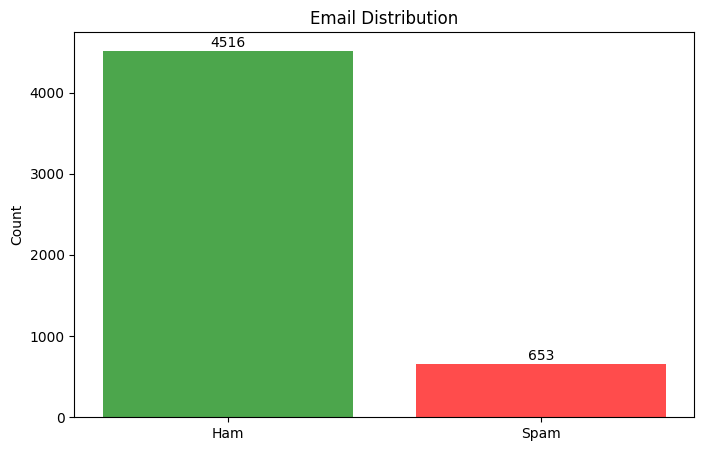

In [204]:
# plot distribution
counts = df['label'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(['Ham', 'Spam'], counts, color=['green', 'red'], alpha=0.7)
plt.title('Email Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

In [205]:
# prepare X and y
X = df['message']
y = df['label']
print(f"X: {X.shape}, y: {y.shape}")

X: (5169,), y: (5169,)


In [206]:
# TF-IDF transformation
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(X)
print(f"TF-IDF shape: {X_tfidf.shape}")

TF-IDF shape: (5169, 5000)


### Why Logistic Regression?

I'm using Logistic Regression because it works well for text classification and it's pretty fast. Also I can see which words are important for spam detection which is helpful for understanding how the model works.

In [207]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 4135, Test: 1034


In [208]:
# Model Optimization

# parameters to try
params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    params,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print(f"\nBest C: {grid.best_params_['C']}")
print(f"Best solver: {grid.best_params_['solver']}")
print(f"Best penalty: {grid.best_params_['penalty']}")
print(f"Best F1 score: {grid.best_score_:.4f}")

model = grid.best_estimator_

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: Convergen


Best C: 10
Best solver: saga
Best penalty: l2
Best F1 score: 0.9129


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Model Optimization

I'm using GridSearchCV to find the best hyperparameter settings for Logistic Regression. This technique is called hyperparameter tuning.

**Parameters being tested:**
- **C (regularization strength):** Controls how strictly the model fits the training data. Lower values = stronger regularization.
- **Solver:** The optimization algorithm used to train the model.
- **Penalty:** Type of regularization (L1 or L2) to prevent overfitting.

**Why this is important:**
- Tests 12 different combinations systematically
- Finds the optimal balance between training accuracy and generalization
- Uses 3-fold cross-validation to ensure results are reliable
- Minimizes false positives (ham marked as spam)

In [209]:
# check training accuracy
train_acc = model.score(X_train, y_train)
print(f"Training accuracy: {train_acc:.4f}")

Training accuracy: 0.9985


In [210]:
# see which words are most important for detecting spam
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# get top spam indicators (positive coefficients)
top_spam_indices = coefficients.argsort()[-15:][::-1]
top_spam_words = [(feature_names[i], coefficients[i]) for i in top_spam_indices]

# get top ham indicators (negative coefficients)
top_ham_indices = coefficients.argsort()[:15]
top_ham_words = [(feature_names[i], coefficients[i]) for i in top_ham_indices]

print("Top 15 SPAM indicators:")
for word, coef in top_spam_words:
    print(f"  {word}: {coef:.4f}")

print("\nTop 15 HAM indicators:")
for word, coef in top_ham_words:
    print(f"  {word}: {coef:.4f}")

Top 15 SPAM indicators:
  50: 7.2117
  mobile: 7.1125
  txt: 6.9941
  uk: 6.9317
  150p: 6.7843
  claim: 6.7463
  www: 6.3342
  won: 5.7235
  service: 5.6400
  sms: 5.2078
  services: 5.0670
  reply: 5.0345
  18: 4.8368
  talk time: 4.7811
  arsenal: 4.7408

Top 15 HAM indicators:
  home: -3.5388
  ok: -3.4554
  did: -2.8858
  lt: -2.8175
  gt: -2.8146
  later: -2.6947
  da: -2.4893
  way: -2.4591
  lt gt: -2.4460
  come: -2.4048
  hey: -2.3802
  ll: -2.3585
  said: -2.3373
  think: -2.3142
  morning: -2.3107


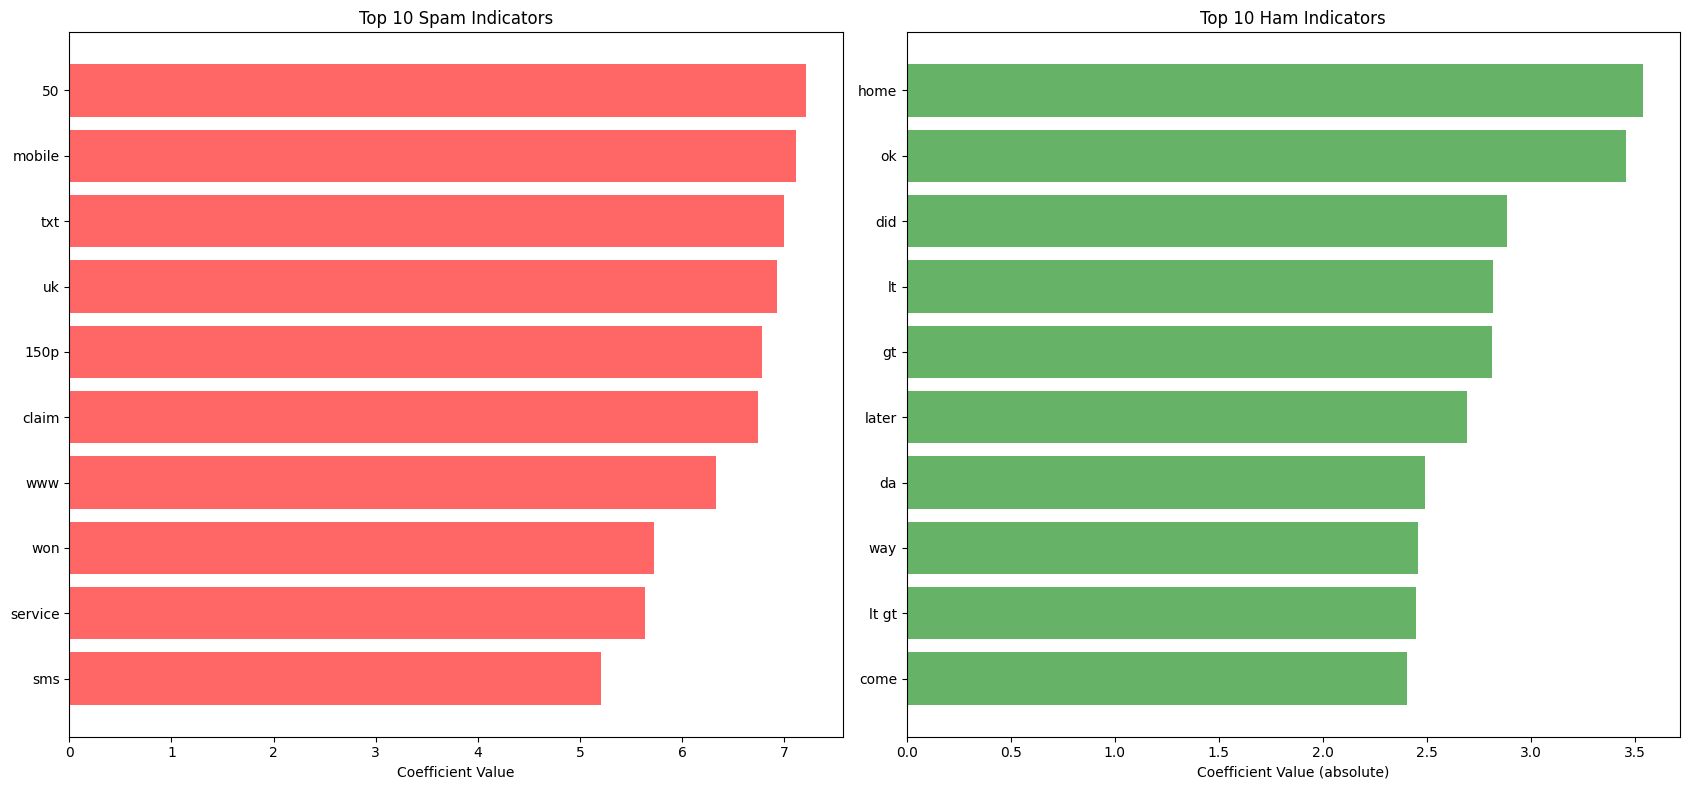

In [211]:
# visualize top features
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))

# spam words
spam_words = [w[0] for w in top_spam_words[:10]]
spam_coefs = [w[1] for w in top_spam_words[:10]]
ax1.barh(spam_words, spam_coefs, color='red', alpha=0.6)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('Top 10 Spam Indicators')
ax1.invert_yaxis()

# ham words
ham_words = [w[0] for w in top_ham_words[:10]]
ham_coefs = [abs(w[1]) for w in top_ham_words[:10]]
ax2.barh(ham_words, ham_coefs, color='green', alpha=0.6)
ax2.set_xlabel('Coefficient Value (absolute)')
ax2.set_title('Top 10 Ham Indicators')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [212]:
# test the model
y_pred = model.predict(X_test)

# calculate accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

# show detailed results
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Test accuracy: 0.9836

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       889
        Spam       0.96      0.92      0.94       145

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.97      1034
weighted avg       0.98      0.98      0.98      1034



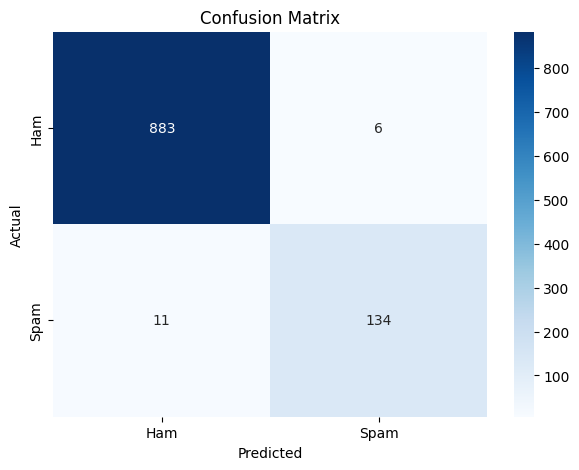

True Negatives: 883
False Positives: 6
False Negatives: 11
True Positives: 134


In [213]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")

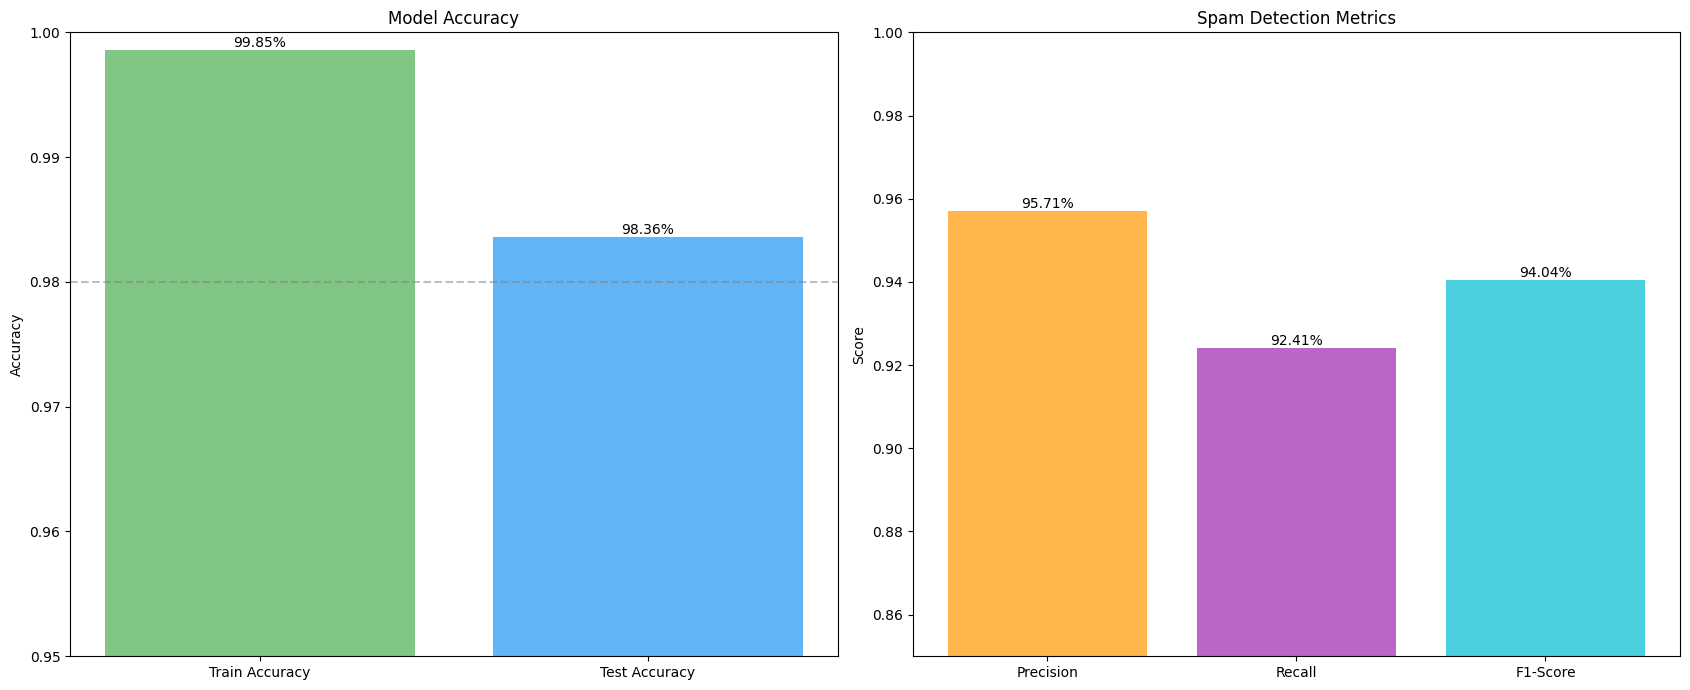

Overall model performance:
  Training: 99.85%
  Testing: 98.36%
  Spam Precision: 95.71%
  Spam Recall: 92.41%
  Spam F1: 94.04%


In [214]:
# visualize overall model performance
fig, ax = plt.subplots(1, 2, figsize=(17, 7))

# accuracy comparison
metrics = ['Train Accuracy', 'Test Accuracy']
scores = [train_acc, test_acc]
colors = ['#4CAF50', '#2196F3']

bars = ax[0].bar(metrics, scores, color=colors, alpha=0.7)
ax[0].set_ylim([0.95, 1.0])
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].axhline(y=0.98, color='gray', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2%}', ha='center', va='bottom')

# spam detection metrics
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics2 = ['Precision', 'Recall', 'F1-Score']
scores2 = [precision, recall, f1]
colors2 = ['#FF9800', '#9C27B0', '#00BCD4']

bars2 = ax[1].bar(metrics2, scores2, color=colors2, alpha=0.7)
ax[1].set_ylim([0.85, 1.0])
ax[1].set_ylabel('Score')
ax[1].set_title('Spam Detection Metrics')

for bar in bars2:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Overall model performance:")
print(f"  Training: {train_acc:.2%}")
print(f"  Testing: {test_acc:.2%}")
print(f"  Spam Precision: {precision:.2%}")
print(f"  Spam Recall: {recall:.2%}")
print(f"  Spam F1: {f1:.2%}")

In [ ]:
# look at some misclassified emails to understand where the model fails


misclassified_indices = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified_indices)}\n")

# get the actual test set indices
test_idx = y_test.index.tolist()

print("Some misclassified examples:\n")
for i in range(min(3, len(misclassified_indices))):
    idx = misclassified_indices[i]
    original_idx = test_idx[idx]
    
    actual = "SPAM" if y_test.iloc[idx] == 1 else "HAM"
    predicted = "SPAM" if y_pred[idx] == 1 else "HAM"
    message = df.loc[original_idx, 'message']
    
    print(f"Example {i+1}:")
    print(f"Message: {message[:100]}...")
    print(f"Actual: {actual} | Predicted: {predicted}")
    print("-"*60 + "\n")

Total misclassified: 17

Some misclassified examples:

Example 1:
Message: Guess who am I?This is the first time I created a web page WWW.ASJESUS.COM read all I wrote. I'm wai...
Actual: SPAM | Predicted: HAM
------------------------------------------------------------

Example 2:
Message: Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 12...
Actual: SPAM | Predicted: HAM
------------------------------------------------------------

Example 3:
Message: Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Lu...
Actual: SPAM | Predicted: HAM
------------------------------------------------------------



In [216]:
# save the model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model saved!")

Model saved!


## Testing

Testing the saved model on new example emails to verify it works correctly.

In [217]:
# load the saved model
with open("spam_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
    
with open("vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)

# test with some new emails
test_emails = [
    "Congratulations! You've won a FREE trip to Bahamas! Click here now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Click this link immediately.",
    "I found that article you were looking for, sending it now."
]

print("Testing on new emails:\n")
for i, email in enumerate(test_emails, 1):
    email_vec = loaded_vectorizer.transform([email])
    prediction = loaded_model.predict(email_vec)[0]
    result = "SPAM" if prediction == 1 else "HAM"
    
    print(f"{i}. {email[:60]}...")
    print(f"   Prediction: {result}\n")

Testing on new emails:

1. Congratulations! You've won a FREE trip to Bahamas! Click he...
   Prediction: SPAM

2. Hey, are we still meeting for lunch tomorrow?...
   Prediction: HAM

3. URGENT: Your account has been compromised. Click this link i...
   Prediction: SPAM

4. I found that article you were looking for, sending it now....
   Prediction: HAM



## Summary

**What I did:**

1. Loaded 5,572 emails from spam.csv
2. Found and removed 403 duplicates → 5,169 unique emails
3. Analyzed data distribution: 4,516 ham (87.4%), 653 spam (12.6%)
4. Noted spam emails are longer on average (138 vs 70 characters)
5. Used TF-IDF to convert text into 5,000 numerical features
6. Split data: 4,135 training (80%), 1,034 testing (20%)
7. Applied GridSearchCV to optimize Logistic Regression:
   - Tested 12 parameter combinations (3 C × 2 solvers × 2 penalties)
   - Used 3-fold cross-validation with F1 scoring
   - Best settings: C=10, solver='saga', penalty='l2'
   - Cross-validation F1: 91.29%
8. Trained model with class_weight='balanced' for imbalanced data
9. Analyzed which words are most important for classification
10. Visualized top 10 spam and ham indicator words
11. Evaluated performance on test set
12. Created confusion matrix and performance visualizations
13. Examined misclassified emails
14. Saved model and vectorizer
15. Tested on new example emails

**Key findings:**

**Top spam indicators:**
- Words: "50", "mobile", "txt", "uk", "150p", "claim"
- Pattern: promotional language, prices, urgency

**Top ham indicators:**
- Words: "home", "ok", "did", "lt", "gt", "later"
- Pattern: casual conversational language

**Model results:**
- Training accuracy: 99.85%
- Test accuracy: 98.36%
- Total errors: 17 out of 1,034 test emails

**Confusion matrix breakdown:**
- True Negatives: 883 (ham correctly identified)
- False Positives: 6 (ham wrongly marked as spam)
- False Negatives: 11 (spam that got through)
- True Positives: 134 (spam correctly caught)

**Spam detection performance:**
- Precision: 96% - when model predicts spam, it's correct 96% of time
- Recall: 92% - catches 92% of all actual spam emails
- F1-score: 94% - balanced precision and recall measure

**Why the model performs well:**
- GridSearchCV systematically found optimal parameters (C=10)
- Saga solver efficiently handles sparse TF-IDF matrices
- L2 penalty provides good generalization without overfitting
- Class balancing ensures minority class (spam) isn't ignored
- TF-IDF captures distinctive spam keywords effectively
- High precision minimizes false alarms for users
- Good recall means most spam is caught